  MLBFD — Multi-Layer Behavioral Fraud Detection
  Phase 1: Data Preparation
✅ Libraries loaded successfully

Using Colab cache for faster access to the 'creditcardfraud' dataset.
✅ Dataset downloaded to: /kaggle/input/creditcardfraud

KAGGLE CREDIT CARD FRAUD DATASET — SUMMARY
Total Transactions : 284,807
Total Features     : 31
Fraud Cases        : 492 (0.173%)
Legitimate Cases   : 284,315 (99.827%)
Missing Values     : 0
Duplicates         : 1081

AMOUNT STATISTICS
                     Legitimate           Fraud
Mean                     ₹88.29         ₹122.21
Median                    ₹22.0           ₹9.25
Max                   ₹25691.16        ₹2125.87
Std Dev                 ₹250.11         ₹256.68

✅ Removed 1081 duplicate rows
   Dataset now: 283,726 rows


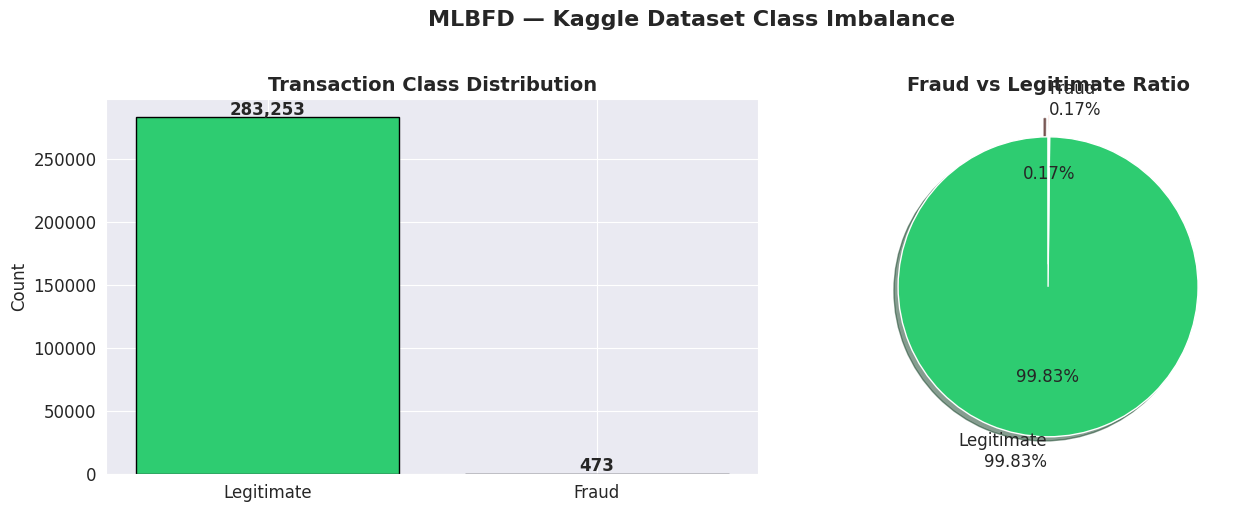

✅ Saved: mlbfd_class_distribution.png


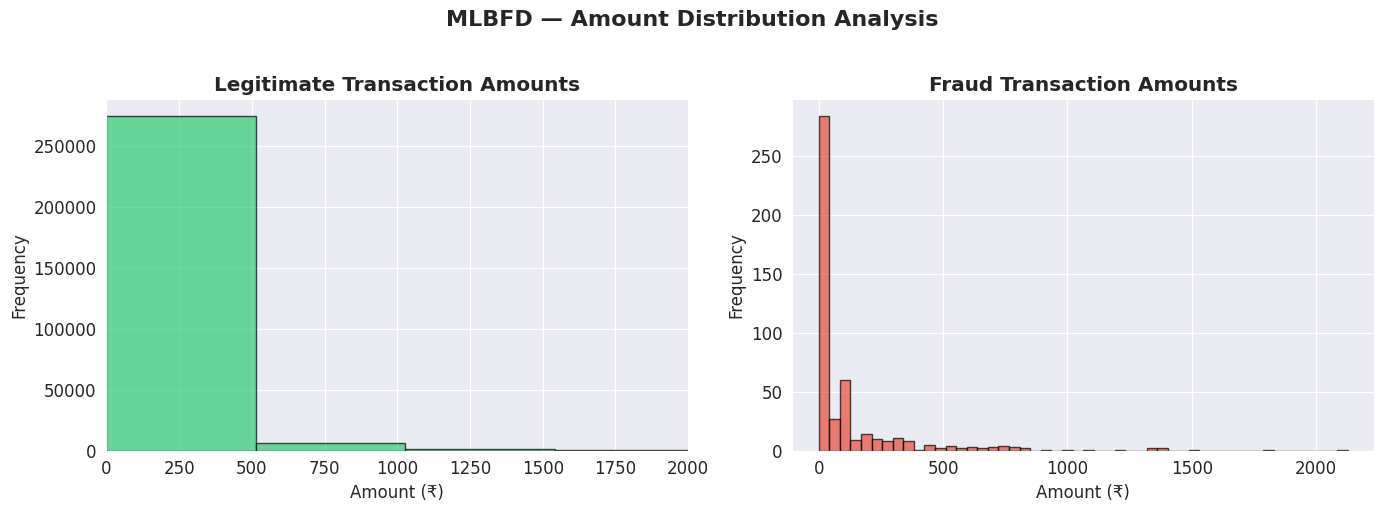

✅ Saved: mlbfd_amount_distribution.png


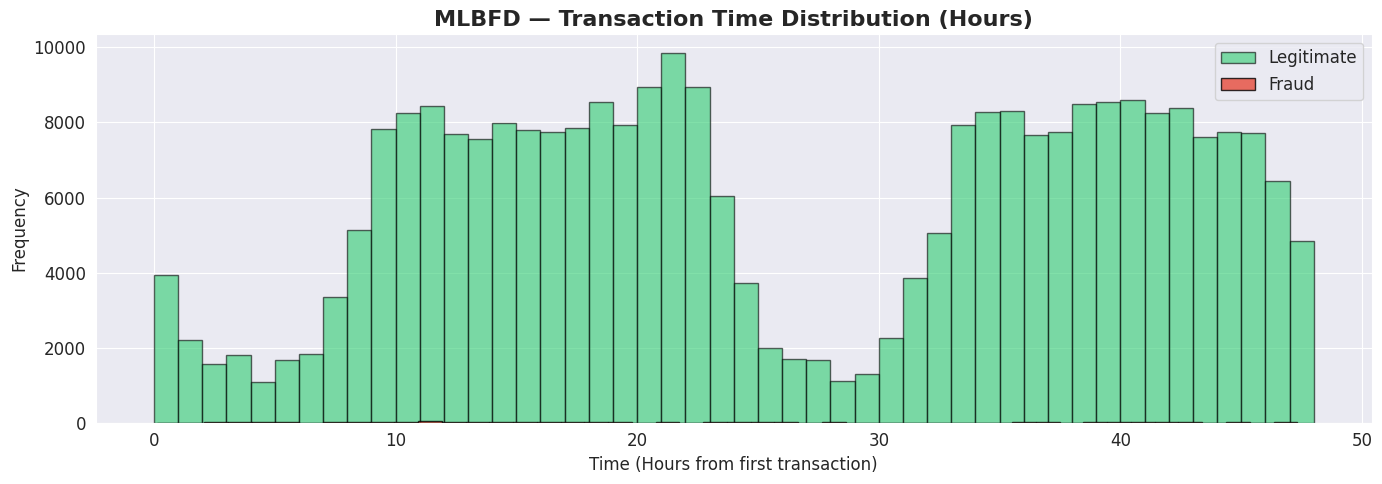

✅ Saved: mlbfd_time_distribution.png


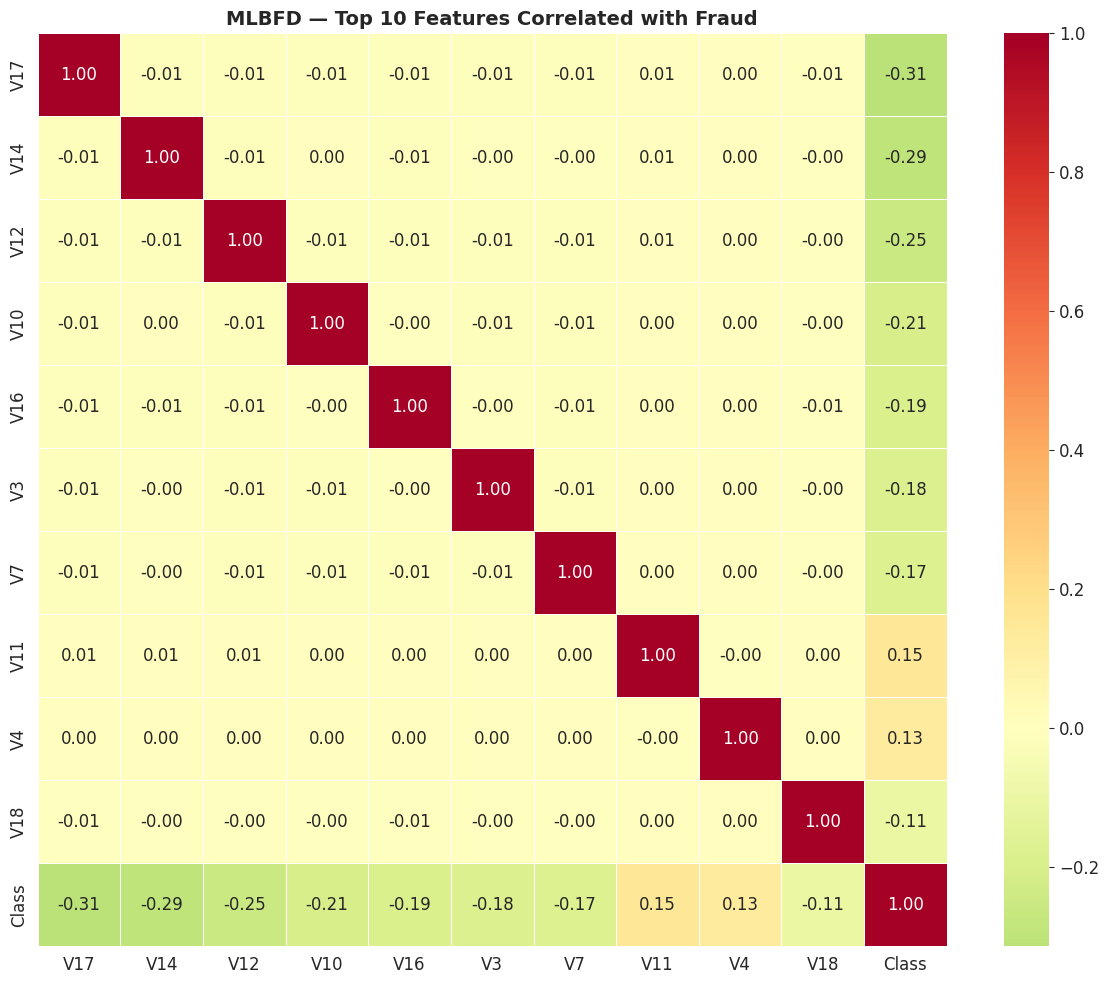

✅ Saved: mlbfd_correlation_heatmap.png

FEATURE ENGINEERING — KAGGLE DATASET
New features added: Amount_Scaled, Hour, Amount_Log, Is_Round_Amount, Is_High_Amount, Is_Night
Total features now: 37

✅ Saved: mlbfd_kaggle_cleaned.csv (283,726 rows, 37 columns)

PHASE 1, STEP 1 — COMPLETE ✅
Dataset loaded     : ✅ 283,726 transactions
Cleaned            : ✅ Duplicates removed, no missing values
Features engineered: ✅ 6 new features added
Visualizations     : ✅ 4 charts saved
Saved to           : ✅ mlbfd_kaggle_cleaned.csv

→ Next: Run Cell 2 — Generate Synthetic Indian Dataset


In [1]:
# ============================================================
# MLBFD — PHASE 1, STEP 1
# Multi-Layer Behavioral Fraud Detection System
# for Indian Digital Payments Using Machine Learning
# ============================================================
# Kaggle Credit Card Fraud Dataset — Load, Clean, Explore
# Notebook: MLBFD_Phase1_Data_Preparation.ipynb
# ============================================================

# --- 1.1 Install & Import Libraries ---
!pip install kagglehub --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visual style
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

PROJECT_NAME = "MLBFD — Multi-Layer Behavioral Fraud Detection"
print(f"{'='*60}")
print(f"  {PROJECT_NAME}")
print(f"  Phase 1: Data Preparation")
print(f"{'='*60}")
print("✅ Libraries loaded successfully\n")

# --- 1.2 Download Kaggle Dataset ---
import kagglehub
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print(f"✅ Dataset downloaded to: {path}")

# --- 1.3 Load Dataset ---
import os
csv_file = os.path.join(path, "creditcard.csv")
df_kaggle = pd.read_csv(csv_file)

print(f"\n{'='*60}")
print(f"KAGGLE CREDIT CARD FRAUD DATASET — SUMMARY")
print(f"{'='*60}")
print(f"Total Transactions : {len(df_kaggle):,}")
print(f"Total Features     : {df_kaggle.shape[1]}")
print(f"Fraud Cases        : {df_kaggle['Class'].sum():,} ({df_kaggle['Class'].mean()*100:.3f}%)")
print(f"Legitimate Cases   : {(df_kaggle['Class']==0).sum():,} ({(1-df_kaggle['Class'].mean())*100:.3f}%)")
print(f"Missing Values     : {df_kaggle.isnull().sum().sum()}")
print(f"Duplicates         : {df_kaggle.duplicated().sum()}")

# --- 1.4 Basic Statistics ---
print(f"\n{'='*60}")
print("AMOUNT STATISTICS")
print(f"{'='*60}")
print(f"{'':15} {'Legitimate':>15} {'Fraud':>15}")
print(f"{'Mean':15} {'₹'+str(round(df_kaggle[df_kaggle.Class==0]['Amount'].mean(),2)):>15} {'₹'+str(round(df_kaggle[df_kaggle.Class==1]['Amount'].mean(),2)):>15}")
print(f"{'Median':15} {'₹'+str(round(df_kaggle[df_kaggle.Class==0]['Amount'].median(),2)):>15} {'₹'+str(round(df_kaggle[df_kaggle.Class==1]['Amount'].median(),2)):>15}")
print(f"{'Max':15} {'₹'+str(round(df_kaggle[df_kaggle.Class==0]['Amount'].max(),2)):>15} {'₹'+str(round(df_kaggle[df_kaggle.Class==1]['Amount'].max(),2)):>15}")
print(f"{'Std Dev':15} {'₹'+str(round(df_kaggle[df_kaggle.Class==0]['Amount'].std(),2)):>15} {'₹'+str(round(df_kaggle[df_kaggle.Class==1]['Amount'].std(),2)):>15}")

# --- 1.5 Remove Duplicates ---
before = len(df_kaggle)
df_kaggle = df_kaggle.drop_duplicates()
after = len(df_kaggle)
print(f"\n✅ Removed {before - after} duplicate rows")
print(f"   Dataset now: {after:,} rows")

# --- 1.6 Visualization 1 — Class Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = df_kaggle['Class'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Legitimate', 'Fraud'], class_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Transaction Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(class_counts.values, labels=['Legitimate\n99.83%', 'Fraud\n0.17%'],
            colors=colors, autopct='%1.2f%%', startangle=90,
            explode=(0, 0.15), shadow=True, textprops={'fontsize': 12})
axes[1].set_title('Fraud vs Legitimate Ratio', fontsize=14, fontweight='bold')

plt.suptitle('MLBFD — Kaggle Dataset Class Imbalance', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('mlbfd_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: mlbfd_class_distribution.png")

# --- 1.7 Visualization 2 — Amount Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_kaggle[df_kaggle.Class==0]['Amount'], bins=50, color='#2ecc71',
             edgecolor='black', alpha=0.7)
axes[0].set_title('Legitimate Transaction Amounts', fontweight='bold')
axes[0].set_xlabel('Amount (₹)')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(0, 2000)

axes[1].hist(df_kaggle[df_kaggle.Class==1]['Amount'], bins=50, color='#e74c3c',
             edgecolor='black', alpha=0.7)
axes[1].set_title('Fraud Transaction Amounts', fontweight='bold')
axes[1].set_xlabel('Amount (₹)')
axes[1].set_ylabel('Frequency')

plt.suptitle('MLBFD — Amount Distribution Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('mlbfd_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: mlbfd_amount_distribution.png")

# --- 1.8 Visualization 3 — Time Distribution ---
fig, ax = plt.subplots(figsize=(14, 5))

ax.hist(df_kaggle[df_kaggle.Class==0]['Time']/3600, bins=48, color='#2ecc71',
        alpha=0.6, label='Legitimate', edgecolor='black')
ax.hist(df_kaggle[df_kaggle.Class==1]['Time']/3600, bins=48, color='#e74c3c',
        alpha=0.8, label='Fraud', edgecolor='black')
ax.set_title('MLBFD — Transaction Time Distribution (Hours)', fontsize=16, fontweight='bold')
ax.set_xlabel('Time (Hours from first transaction)')
ax.set_ylabel('Frequency')
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('mlbfd_time_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: mlbfd_time_distribution.png")

# --- 1.9 Visualization 4 — Correlation Heatmap (Top Features) ---
correlations = df_kaggle.corr()['Class'].drop('Class').abs().sort_values(ascending=False)
top_features = correlations.head(10).index.tolist() + ['Class']

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df_kaggle[top_features].corr(), annot=True, cmap='RdYlGn_r',
            center=0, fmt='.2f', linewidths=0.5, ax=ax)
ax.set_title('MLBFD — Top 10 Features Correlated with Fraud', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('mlbfd_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: mlbfd_correlation_heatmap.png")

# --- 1.10 Feature Engineering on Kaggle Data ---
print(f"\n{'='*60}")
print("FEATURE ENGINEERING — KAGGLE DATASET")
print(f"{'='*60}")

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_kaggle['Amount_Scaled'] = scaler.fit_transform(df_kaggle[['Amount']])

df_kaggle['Hour'] = (df_kaggle['Time'] / 3600).astype(int) % 24
df_kaggle['Amount_Log'] = np.log1p(df_kaggle['Amount'])
df_kaggle['Is_Round_Amount'] = (df_kaggle['Amount'] % 100 == 0).astype(int)
df_kaggle['Is_High_Amount'] = (df_kaggle['Amount'] > df_kaggle['Amount'].quantile(0.95)).astype(int)
df_kaggle['Is_Night'] = ((df_kaggle['Hour'] >= 23) | (df_kaggle['Hour'] <= 5)).astype(int)

print(f"New features added: Amount_Scaled, Hour, Amount_Log, Is_Round_Amount, Is_High_Amount, Is_Night")
print(f"Total features now: {df_kaggle.shape[1]}")

# --- 1.11 Save Cleaned Kaggle Dataset ---
df_kaggle.to_csv('mlbfd_kaggle_cleaned.csv', index=False)
print(f"\n✅ Saved: mlbfd_kaggle_cleaned.csv ({len(df_kaggle):,} rows, {df_kaggle.shape[1]} columns)")

# --- 1.12 Summary ---
print(f"\n{'='*60}")
print("PHASE 1, STEP 1 — COMPLETE ✅")
print(f"{'='*60}")
print(f"Dataset loaded     : ✅ {len(df_kaggle):,} transactions")
print(f"Cleaned            : ✅ Duplicates removed, no missing values")
print(f"Features engineered: ✅ 6 new features added")
print(f"Visualizations     : ✅ 4 charts saved")
print(f"Saved to           : ✅ mlbfd_kaggle_cleaned.csv")
print(f"\n→ Next: Run Cell 2 — Generate Synthetic Indian Dataset")

  MLBFD — Multi-Layer Behavioral Fraud Detection
  Phase 1, Step 2: Indian Synthetic Data Generation
✅ Faker (en_IN) initialized

GENERATING USER PROFILES (UBTS FOUNDATION)
✅ Generated 1000 user profiles
   States covered: 29
   Account age range: 188 - 1799 days
   Preferred apps: {'GPay': 348, 'PhonePe': 297, 'Paytm': 155, 'BHIM': 74, 'WhatsAppPay': 63, 'AmazonPay': 63}

GENERATING TRANSACTIONS

Generating 47,500 legitimate transactions...
Generating 2,500 fraud transactions...
  → vishing: 1,175 transactions
  → fake_collect: 525 transactions
  → sim_swap: 300 transactions
  → phishing: 500 transactions

✅ Generated 50,000 Indian transactions — NO ERRORS!

SYNTHETIC INDIAN DATASET — SUMMARY
Total Transactions  : 50,000
Fraud Cases         : 2,500 (5.0%)
Legitimate Cases    : 47,500
Unique Users        : 1,000
Features            : 28

--- Fraud Type Breakdown ---
  vishing         : 1,175 (47.0%)
  fake_collect    :   525 (21.0%)
  phishing        :   500 (20.0%)
  sim_swap        :

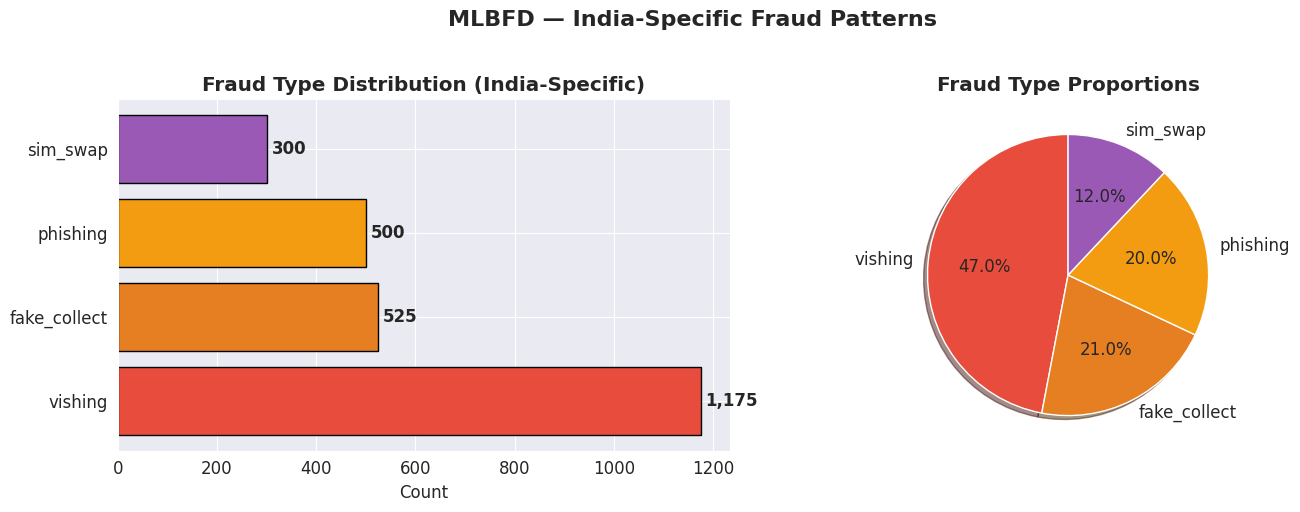

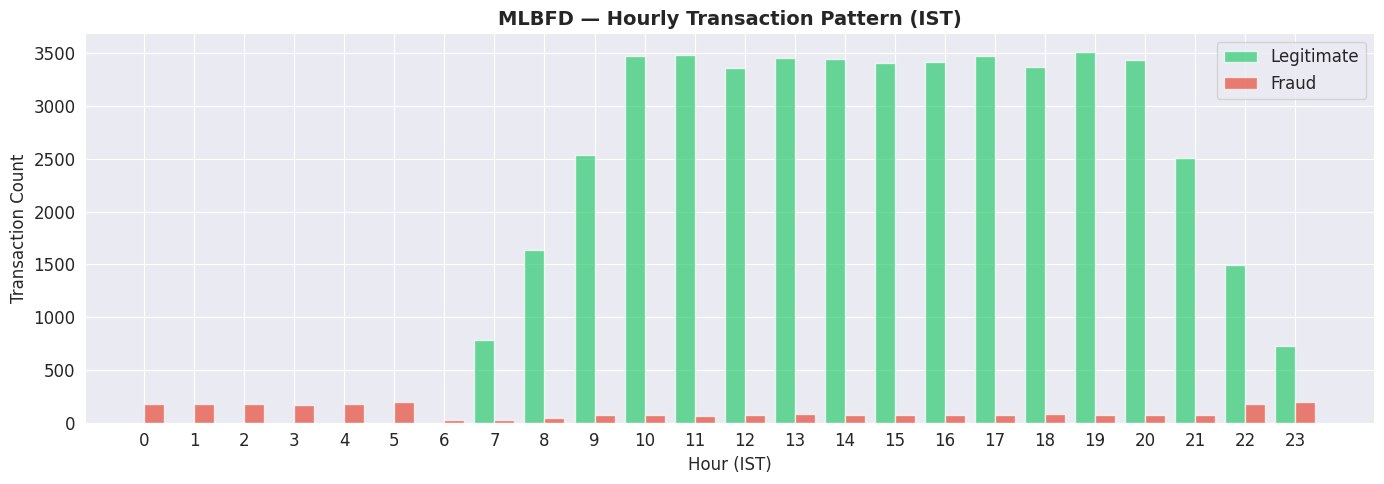

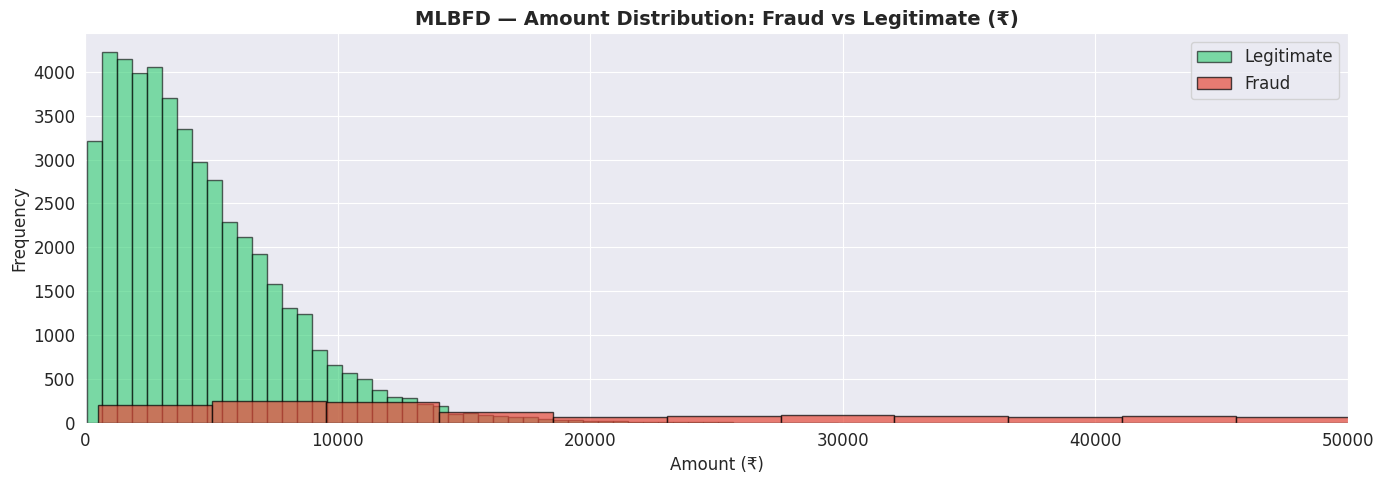

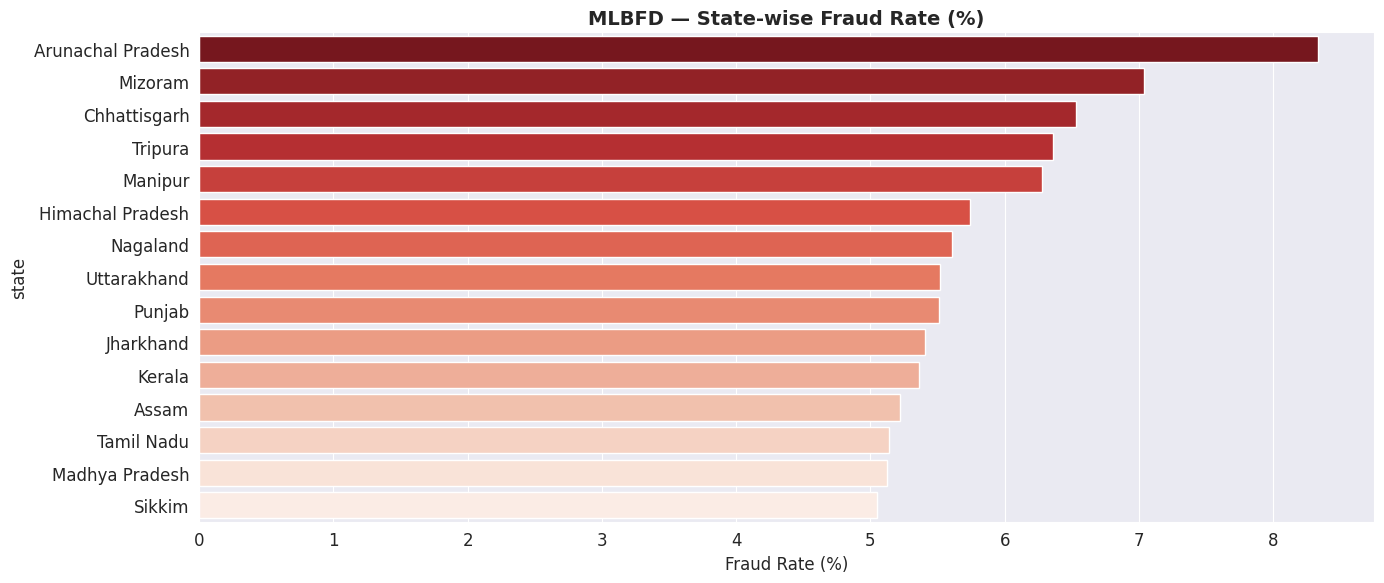

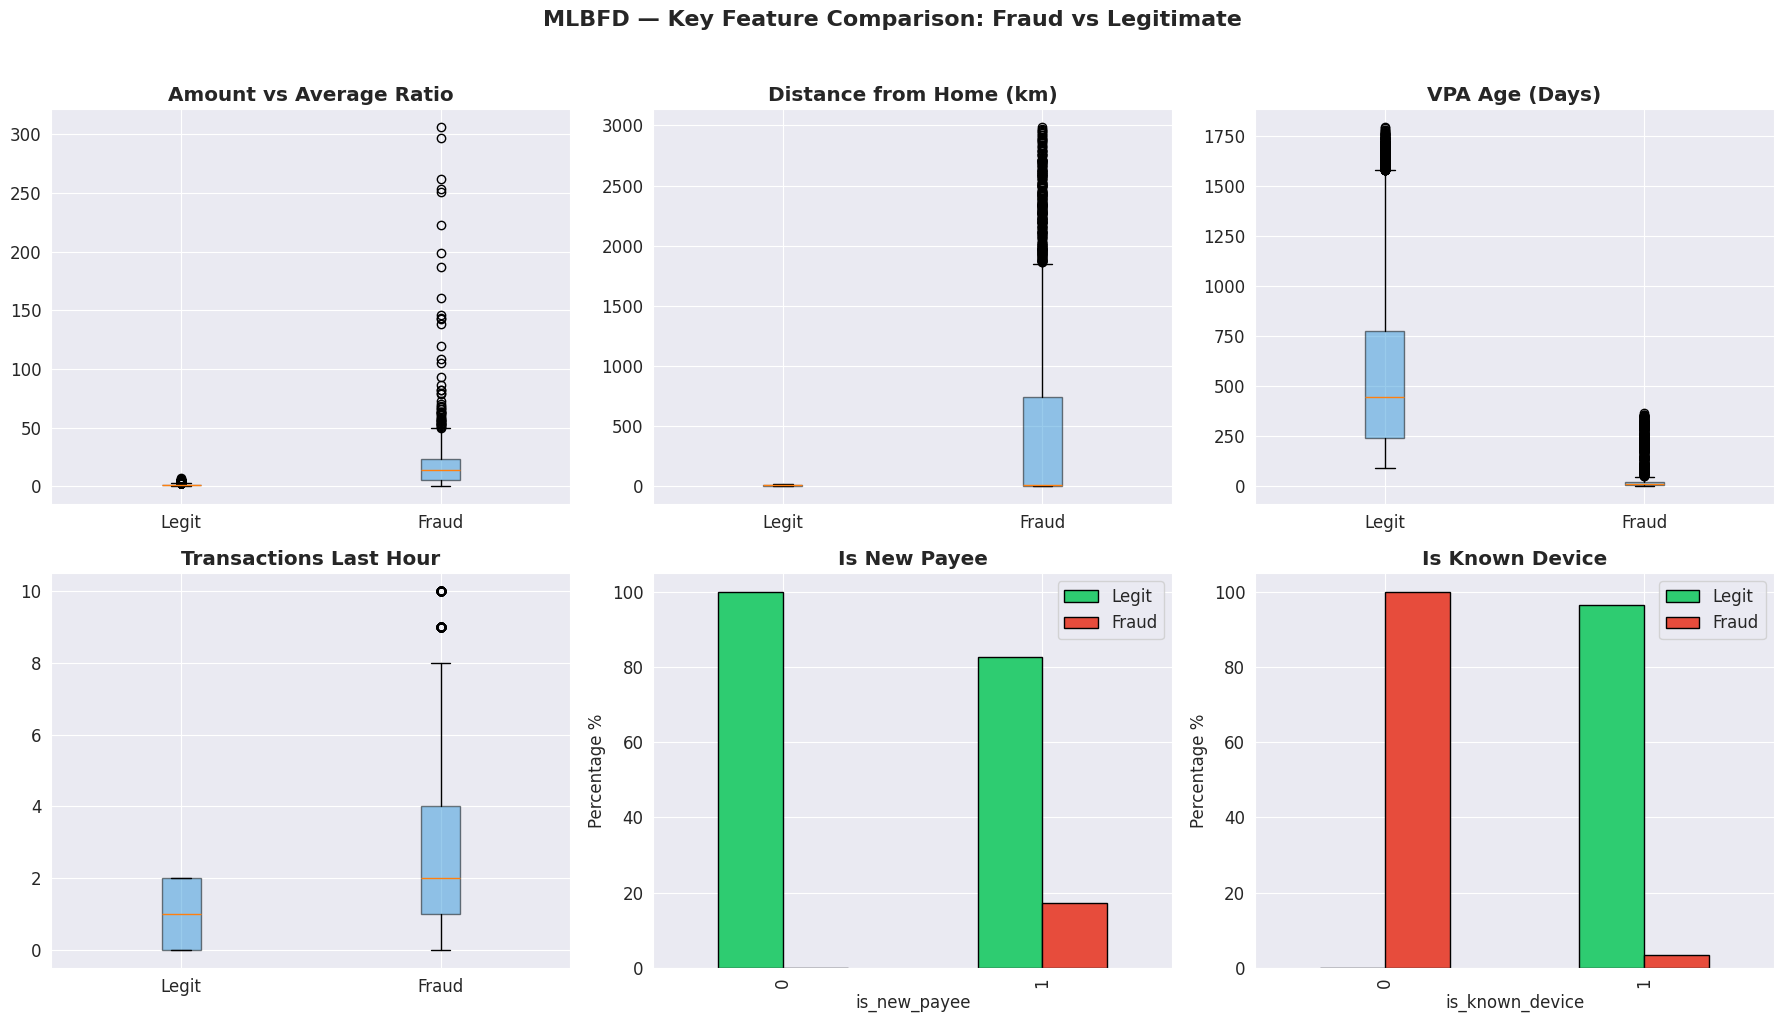


✅ All visualizations saved!

✅ Saved: mlbfd_indian_synthetic.csv (50,000 rows)
✅ Saved: mlbfd_user_profiles.csv (1,000 users)

→ Next: Run Cell 3 — Combine Datasets & Feature Engineering


In [4]:
# ============================================================
# MLBFD — PHASE 1, STEP 2 (FIXED)
# Multi-Layer Behavioral Fraud Detection System
# for Indian Digital Payments Using Machine Learning
# ============================================================
# Synthetic Indian UPI/Card Dataset Generation (Faker en_IN)
# Notebook: MLBFD_Phase1_Data_Preparation.ipynb
# ============================================================

!pip install faker --quiet

import pandas as pd
import numpy as np
from faker import Faker
import random
import uuid
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

fake = Faker('en_IN')
Faker.seed(42)
np.random.seed(42)
random.seed(42)

PROJECT_NAME = "MLBFD — Multi-Layer Behavioral Fraud Detection"
print(f"{'='*60}")
print(f"  {PROJECT_NAME}")
print(f"  Phase 1, Step 2: Indian Synthetic Data Generation")
print(f"{'='*60}")
print("✅ Faker (en_IN) initialized\n")

# ============================================================
# CONFIGURATION
# ============================================================
NUM_USERS = 1000
NUM_TRANSACTIONS = 50000
FRAUD_RATIO = 0.05

# --- Indian States with Risk Levels ---
INDIAN_STATES = {
    'Maharashtra': 0.3, 'Karnataka': 0.2, 'Delhi': 0.25,
    'Tamil Nadu': 0.15, 'Telangana': 0.15, 'Gujarat': 0.12,
    'Uttar Pradesh': 0.2, 'West Bengal': 0.18, 'Rajasthan': 0.14,
    'Kerala': 0.1, 'Madhya Pradesh': 0.13, 'Punjab': 0.11,
    'Haryana': 0.16, 'Bihar': 0.22, 'Andhra Pradesh': 0.12,
    'Odisha': 0.11, 'Jharkhand': 0.19, 'Assam': 0.1,
    'Chhattisgarh': 0.12, 'Goa': 0.08, 'Himachal Pradesh': 0.06,
    'Uttarakhand': 0.09, 'Tripura': 0.07, 'Meghalaya': 0.06,
    'Manipur': 0.05, 'Nagaland': 0.05, 'Mizoram': 0.04,
    'Sikkim': 0.04, 'Arunachal Pradesh': 0.03
}

PAYMENT_APPS = ['GPay', 'PhonePe', 'Paytm', 'BHIM', 'AmazonPay', 'WhatsAppPay']
PAYMENT_APP_WEIGHTS = [0.35, 0.30, 0.15, 0.08, 0.07, 0.05]

MERCHANT_CATEGORIES = [
    'food_delivery', 'grocery', 'fuel', 'shopping', 'recharge',
    'electricity', 'rent', 'education', 'medical', 'travel',
    'entertainment', 'transfer_p2p', 'insurance', 'investment'
]

PAYMENT_TYPES = ['UPI', 'Card', 'NetBanking']
PAYMENT_TYPE_WEIGHTS = [0.72, 0.20, 0.08]

# ============================================================
# STEP 2.1 — Generate User Profiles (UBTS Foundation)
# ============================================================
print(f"{'='*60}")
print("GENERATING USER PROFILES (UBTS FOUNDATION)")
print(f"{'='*60}")

def generate_user_profiles(num_users):
    """Generate realistic Indian user profiles for UBTS baseline"""
    users = []
    for i in range(num_users):
        home_state = random.choices(list(INDIAN_STATES.keys()),
                                     weights=list(INDIAN_STATES.values()))[0]
        home_city = fake.city()
        preferred_app = random.choices(PAYMENT_APPS, weights=PAYMENT_APP_WEIGHTS)[0]

        user = {
            'user_id': f'USR_{i+1:04d}',
            'name': fake.name(),
            'phone': fake.phone_number(),
            'upi_vpa': f"{fake.user_name()}@{random.choice(['okaxis', 'oksbi', 'okhdfcbank', 'ybl', 'paytm', 'ibl'])}",
            'home_state': home_state,
            'home_city': home_city,
            'preferred_app': preferred_app,
            'usual_hour_start': random.randint(7, 10),
            'usual_hour_end': random.randint(20, 23),
            'avg_amount': round(random.uniform(200, 8000), 2),
            'max_usual_amount': round(random.uniform(5000, 25000), 2),
            'avg_daily_transactions': random.randint(2, 8),
            'usual_merchants': random.sample(MERCHANT_CATEGORIES, k=random.randint(3, 7)),
            'known_payees': [f"{fake.user_name()}@{random.choice(['okaxis', 'ybl', 'paytm'])}"
                           for _ in range(random.randint(5, 20))],
            'account_age_days': random.randint(180, 1800),  # 🔧 FIX: Minimum 180 days (was 30)
            'device_id': str(uuid.uuid4())[:8],
            'usual_device_model': random.choice(['Samsung', 'Xiaomi', 'OnePlus', 'Vivo',
                                                  'Oppo', 'Realme', 'iPhone', 'Poco']),
            'risk_tolerance': random.uniform(0.1, 0.9)
        }
        users.append(user)

    return pd.DataFrame(users)

df_users = generate_user_profiles(NUM_USERS)
print(f"✅ Generated {NUM_USERS} user profiles")
print(f"   States covered: {df_users['home_state'].nunique()}")
print(f"   Account age range: {df_users['account_age_days'].min()} - {df_users['account_age_days'].max()} days")
print(f"   Preferred apps: {df_users['preferred_app'].value_counts().to_dict()}")

# ============================================================
# STEP 2.2 — Generate Transactions
# ============================================================
print(f"\n{'='*60}")
print("GENERATING TRANSACTIONS")
print(f"{'='*60}")

def generate_legitimate_transaction(user, transaction_id):
    """Generate a NORMAL transaction matching user's baseline"""
    hour = random.randint(user['usual_hour_start'], user['usual_hour_end'])
    amount = round(np.random.lognormal(
        mean=np.log(user['avg_amount']),
        sigma=0.5
    ), 2)
    amount = min(amount, user['max_usual_amount'] * 1.2)
    amount = max(amount, 10)

    merchant = random.choice(user['usual_merchants'])
    is_known_payee = random.random() < 0.75

    if is_known_payee and user['known_payees']:
        payee_vpa = random.choice(user['known_payees'])
    else:
        payee_vpa = f"{fake.user_name()}@{random.choice(['okaxis', 'ybl', 'paytm', 'okhdfcbank'])}"

    txn_date = fake.date_time_between(start_date='-90d', end_date='now')
    txn_date = txn_date.replace(hour=hour, minute=random.randint(0, 59))

    # 🔧 FIX: Ensure vpa_age_days range is always valid
    vpa_age_min = 90
    vpa_age_max = max(vpa_age_min, user['account_age_days'])

    return {
        'transaction_id': f'TXN_{transaction_id:06d}',
        'user_id': user['user_id'],
        'amount_inr': round(amount, 2),
        'hour_ist': hour,
        'day_of_week': txn_date.weekday(),
        'timestamp': txn_date,
        'payment_type': random.choices(PAYMENT_TYPES, weights=PAYMENT_TYPE_WEIGHTS)[0],
        'payment_app': user['preferred_app'] if random.random() < 0.7 else random.choice(PAYMENT_APPS),
        'merchant_category': merchant,
        'payee_vpa': payee_vpa,
        'payer_vpa': user['upi_vpa'],
        'is_new_payee': 0 if is_known_payee else 1,
        'is_known_device': 1,
        'device_id': user['device_id'],
        'device_model': user['usual_device_model'],
        'state': user['home_state'],
        'city': user['home_city'],
        'is_usual_location': 1,
        'distance_from_home_km': round(random.uniform(0, 15), 1),
        'vpa_age_days': random.randint(vpa_age_min, vpa_age_max),  # 🔧 FIX: Safe range
        'is_round_number': 1 if amount % 100 == 0 else 0,
        'amount_vs_avg_ratio': round(amount / user['avg_amount'], 2),
        'transactions_last_hour': random.randint(0, 2),
        'transactions_last_24h': random.randint(1, user['avg_daily_transactions']),
        'is_vpn': 0,
        'is_collect_request': 0,
        'fraud_type': 'none',
        'is_fraud': 0
    }


def generate_fraud_transaction(user, transaction_id, fraud_type):
    """Generate a FRAUDULENT transaction based on India-specific fraud patterns"""

    if fraud_type == 'vishing':
        hour = random.choice([0, 1, 2, 3, 4, 5, 22, 23])
        amount = round(user['avg_amount'] * random.uniform(5, 50), 2)
        amount = min(amount, 100000)
        return _build_fraud_txn(user, transaction_id, fraud_type,
                                 hour=hour, amount=amount,
                                 is_new_payee=1, is_known_device=1,
                                 is_usual_location=1, distance=round(random.uniform(0, 10), 1),
                                 is_vpn=0, is_collect=0,
                                 vpa_age=random.randint(1, 30))

    elif fraud_type == 'fake_collect':
        hour = random.randint(9, 21)
        amount = round(random.uniform(500, 15000), 2)
        return _build_fraud_txn(user, transaction_id, fraud_type,
                                 hour=hour, amount=amount,
                                 is_new_payee=1, is_known_device=1,
                                 is_usual_location=1, distance=round(random.uniform(0, 10), 1),
                                 is_vpn=0, is_collect=1,
                                 vpa_age=random.randint(1, 15))

    elif fraud_type == 'sim_swap':
        hour = random.randint(0, 23)
        amount = round(user['avg_amount'] * random.uniform(3, 30), 2)
        diff_state = random.choice([s for s in INDIAN_STATES.keys() if s != user['home_state']])
        return _build_fraud_txn(user, transaction_id, fraud_type,
                                 hour=hour, amount=amount,
                                 is_new_payee=1, is_known_device=0,
                                 is_usual_location=0, distance=round(random.uniform(200, 2500), 1),
                                 is_vpn=random.choice([0, 1]), is_collect=0,
                                 vpa_age=random.randint(30, 365),
                                 override_state=diff_state,
                                 high_velocity=True)

    elif fraud_type == 'phishing':
        hour = random.randint(0, 23)
        amount = round(random.uniform(2000, 80000), 2)
        return _build_fraud_txn(user, transaction_id, fraud_type,
                                 hour=hour, amount=amount,
                                 is_new_payee=1, is_known_device=0,
                                 is_usual_location=0, distance=round(random.uniform(100, 3000), 1),
                                 is_vpn=random.choice([0, 1]), is_collect=0,
                                 vpa_age=random.randint(1, 10),
                                 high_velocity=True)


def _build_fraud_txn(user, txn_id, fraud_type, hour, amount, is_new_payee,
                      is_known_device, is_usual_location, distance, is_vpn,
                      is_collect, vpa_age, override_state=None, high_velocity=False):
    """Helper to build a fraud transaction record"""

    txn_date = fake.date_time_between(start_date='-90d', end_date='now')
    txn_date = txn_date.replace(hour=hour, minute=random.randint(0, 59))

    fraud_vpa = f"{fake.user_name()}{random.randint(1,999)}@{random.choice(['okaxis', 'ybl', 'paytm'])}"

    # 🔧 FIX: Ensure transactions_last_24h max is always valid
    max_daily = max(user['avg_daily_transactions'], 2)

    return {
        'transaction_id': f'TXN_{txn_id:06d}',
        'user_id': user['user_id'],
        'amount_inr': round(amount, 2),
        'hour_ist': hour,
        'day_of_week': txn_date.weekday(),
        'timestamp': txn_date,
        'payment_type': random.choices(PAYMENT_TYPES, weights=PAYMENT_TYPE_WEIGHTS)[0],
        'payment_app': random.choice(PAYMENT_APPS),
        'merchant_category': random.choice(MERCHANT_CATEGORIES),
        'payee_vpa': fraud_vpa,
        'payer_vpa': user['upi_vpa'],
        'is_new_payee': is_new_payee,
        'is_known_device': is_known_device,
        'device_id': user['device_id'] if is_known_device else str(uuid.uuid4())[:8],
        'device_model': user['usual_device_model'] if is_known_device else random.choice(
            ['Samsung', 'Xiaomi', 'OnePlus', 'Vivo', 'Unknown']),
        'state': override_state if override_state else user['home_state'],
        'city': fake.city() if not is_usual_location else user['home_city'],
        'is_usual_location': is_usual_location,
        'distance_from_home_km': distance,
        'vpa_age_days': vpa_age,
        'is_round_number': 1 if amount % 1000 == 0 else 0,
        'amount_vs_avg_ratio': round(amount / max(user['avg_amount'], 1), 2),
        'transactions_last_hour': random.randint(3, 10) if high_velocity else random.randint(0, 2),
        'transactions_last_24h': random.randint(8, 25) if high_velocity else random.randint(1, max_daily),
        'is_vpn': is_vpn,
        'is_collect_request': is_collect,
        'fraud_type': fraud_type,
        'is_fraud': 1
    }


# --- Generate all transactions ---
transactions = []
num_fraud = int(NUM_TRANSACTIONS * FRAUD_RATIO)
num_legit = NUM_TRANSACTIONS - num_fraud

fraud_distribution = {
    'vishing': int(num_fraud * 0.47),
    'fake_collect': int(num_fraud * 0.21),
    'sim_swap': int(num_fraud * 0.12),
    'phishing': int(num_fraud * 0.20)
}

print(f"\nGenerating {num_legit:,} legitimate transactions...")
txn_id = 1
for _ in range(num_legit):
    user = df_users.iloc[random.randint(0, NUM_USERS - 1)]
    transactions.append(generate_legitimate_transaction(user, txn_id))
    txn_id += 1

print(f"Generating {num_fraud:,} fraud transactions...")
for fraud_type, count in fraud_distribution.items():
    print(f"  → {fraud_type}: {count:,} transactions")
    for _ in range(count):
        user = df_users.iloc[random.randint(0, NUM_USERS - 1)]
        transactions.append(generate_fraud_transaction(user, txn_id, fraud_type))
        txn_id += 1

df_indian = pd.DataFrame(transactions)
df_indian = df_indian.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n✅ Generated {len(df_indian):,} Indian transactions — NO ERRORS!")

# ============================================================
# STEP 2.3 — Dataset Statistics
# ============================================================
print(f"\n{'='*60}")
print("SYNTHETIC INDIAN DATASET — SUMMARY")
print(f"{'='*60}")
print(f"Total Transactions  : {len(df_indian):,}")
print(f"Fraud Cases         : {df_indian['is_fraud'].sum():,} ({df_indian['is_fraud'].mean()*100:.1f}%)")
print(f"Legitimate Cases    : {(df_indian['is_fraud']==0).sum():,}")
print(f"Unique Users        : {df_indian['user_id'].nunique():,}")
print(f"Features            : {df_indian.shape[1]}")

print(f"\n--- Fraud Type Breakdown ---")
fraud_counts = df_indian[df_indian['is_fraud']==1]['fraud_type'].value_counts()
for ft, count in fraud_counts.items():
    pct = count / df_indian['is_fraud'].sum() * 100
    print(f"  {ft:15} : {count:5,} ({pct:.1f}%)")

print(f"\n--- Payment Type Distribution ---")
for pt, count in df_indian['payment_type'].value_counts().items():
    print(f"  {pt:15} : {count:6,} ({count/len(df_indian)*100:.1f}%)")

print(f"\n--- Top 5 States ---")
for state, count in df_indian['state'].value_counts().head().items():
    print(f"  {state:20} : {count:6,}")

print(f"\n--- Payment App Distribution ---")
for app, count in df_indian['payment_app'].value_counts().items():
    print(f"  {app:15} : {count:6,} ({count/len(df_indian)*100:.1f}%)")

# ============================================================
# STEP 2.4 — Indian Dataset Visualizations
# ============================================================

# Viz 1: Fraud Type Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fraud_data = df_indian[df_indian['is_fraud']==1]['fraud_type'].value_counts()
colors_fraud = ['#e74c3c', '#e67e22', '#f39c12', '#9b59b6']

axes[0].barh(fraud_data.index, fraud_data.values, color=colors_fraud, edgecolor='black')
axes[0].set_title('Fraud Type Distribution (India-Specific)', fontweight='bold')
axes[0].set_xlabel('Count')
for i, v in enumerate(fraud_data.values):
    axes[0].text(v + 10, i, f'{v:,}', va='center', fontweight='bold')

axes[1].pie(fraud_data.values, labels=fraud_data.index, colors=colors_fraud,
            autopct='%1.1f%%', startangle=90, shadow=True)
axes[1].set_title('Fraud Type Proportions', fontweight='bold')

plt.suptitle('MLBFD — India-Specific Fraud Patterns', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('mlbfd_indian_fraud_types.png', dpi=150, bbox_inches='tight')
plt.show()

# Viz 2: Hourly Fraud Pattern
fig, ax = plt.subplots(figsize=(14, 5))
legit_hours = df_indian[df_indian['is_fraud']==0]['hour_ist'].value_counts().sort_index()
fraud_hours = df_indian[df_indian['is_fraud']==1]['hour_ist'].value_counts().sort_index()

ax.bar(legit_hours.index - 0.2, legit_hours.values, width=0.4, color='#2ecc71',
       label='Legitimate', alpha=0.7)
ax.bar(fraud_hours.index + 0.2, fraud_hours.values, width=0.4, color='#e74c3c',
       label='Fraud', alpha=0.7)
ax.set_title('MLBFD — Hourly Transaction Pattern (IST)', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour (IST)')
ax.set_ylabel('Transaction Count')
ax.set_xticks(range(24))
ax.legend()
plt.tight_layout()
plt.savefig('mlbfd_hourly_pattern.png', dpi=150, bbox_inches='tight')
plt.show()

# Viz 3: Amount Distribution — Fraud vs Legit
fig, ax = plt.subplots(figsize=(14, 5))
ax.hist(df_indian[df_indian['is_fraud']==0]['amount_inr'], bins=50, color='#2ecc71',
        alpha=0.6, label='Legitimate', edgecolor='black')
ax.hist(df_indian[df_indian['is_fraud']==1]['amount_inr'], bins=50, color='#e74c3c',
        alpha=0.7, label='Fraud', edgecolor='black')
ax.set_title('MLBFD — Amount Distribution: Fraud vs Legitimate (₹)', fontsize=14, fontweight='bold')
ax.set_xlabel('Amount (₹)')
ax.set_ylabel('Frequency')
ax.legend()
ax.set_xlim(0, 50000)
plt.tight_layout()
plt.savefig('mlbfd_amount_fraud_vs_legit.png', dpi=150, bbox_inches='tight')
plt.show()

# Viz 4: State-wise Fraud Heatmap
fig, ax = plt.subplots(figsize=(14, 6))
state_fraud = df_indian.groupby('state')['is_fraud'].mean().sort_values(ascending=False).head(15)
sns.barplot(x=state_fraud.values * 100, y=state_fraud.index, palette='Reds_r', ax=ax)
ax.set_title('MLBFD — State-wise Fraud Rate (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Fraud Rate (%)')
plt.tight_layout()
plt.savefig('mlbfd_state_fraud_rate.png', dpi=150, bbox_inches='tight')
plt.show()

# Viz 5: Feature Importance Preview — Key Fraud Indicators
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

features_to_plot = [
    ('amount_vs_avg_ratio', 'Amount vs Average Ratio'),
    ('distance_from_home_km', 'Distance from Home (km)'),
    ('vpa_age_days', 'VPA Age (Days)'),
    ('transactions_last_hour', 'Transactions Last Hour'),
    ('is_new_payee', 'Is New Payee'),
    ('is_known_device', 'Is Known Device')
]

for idx, (feat, title) in enumerate(features_to_plot):
    row, col = idx // 3, idx % 3
    ax = axes[row][col]

    if df_indian[feat].nunique() <= 2:
        ct = pd.crosstab(df_indian[feat], df_indian['is_fraud'], normalize='index') * 100
        ct.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], edgecolor='black')
        ax.set_ylabel('Percentage %')
        ax.legend(['Legit', 'Fraud'])
    else:
        data_legit = df_indian[df_indian['is_fraud']==0][feat]
        data_fraud = df_indian[df_indian['is_fraud']==1][feat]
        ax.boxplot([data_legit, data_fraud], labels=['Legit', 'Fraud'],
                   patch_artist=True, boxprops=dict(facecolor='#3498db', alpha=0.5))

    ax.set_title(title, fontweight='bold')

plt.suptitle('MLBFD — Key Feature Comparison: Fraud vs Legitimate',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('mlbfd_feature_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ All visualizations saved!")

# ============================================================
# STEP 2.5 — Save Everything
# ============================================================
df_indian.to_csv('mlbfd_indian_synthetic.csv', index=False)
df_users.to_csv('mlbfd_user_profiles.csv', index=False)

print(f"\n✅ Saved: mlbfd_indian_synthetic.csv ({len(df_indian):,} rows)")
print(f"✅ Saved: mlbfd_user_profiles.csv ({len(df_users):,} users)")
print(f"\n→ Next: Run Cell 3 — Combine Datasets & Feature Engineering")

  MLBFD — Multi-Layer Behavioral Fraud Detection
  Phase 1, Step 3: Combine & Feature Engineering

🔍 Locating dataset files...

DATASETS LOADED SUCCESSFULLY
Kaggle dataset  : 283,726 rows, 37 cols
Indian dataset  : 50,000 rows, 28 cols

📊 Mapping Kaggle features to Indian format...
✅ Kaggle dataset mapped to Indian format

📊 Merging datasets on 52 common columns...

COMBINED DATASET — SUMMARY
Total Transactions  : 333,726
Total Features      : 52
Fraud Cases         : 2,973 (0.89%)
Legitimate Cases    : 330,753

ADVANCED FEATURE ENGINEERING
✅ Added 10 engineered features
   Total features now: 62

📊 Generating visualizations...


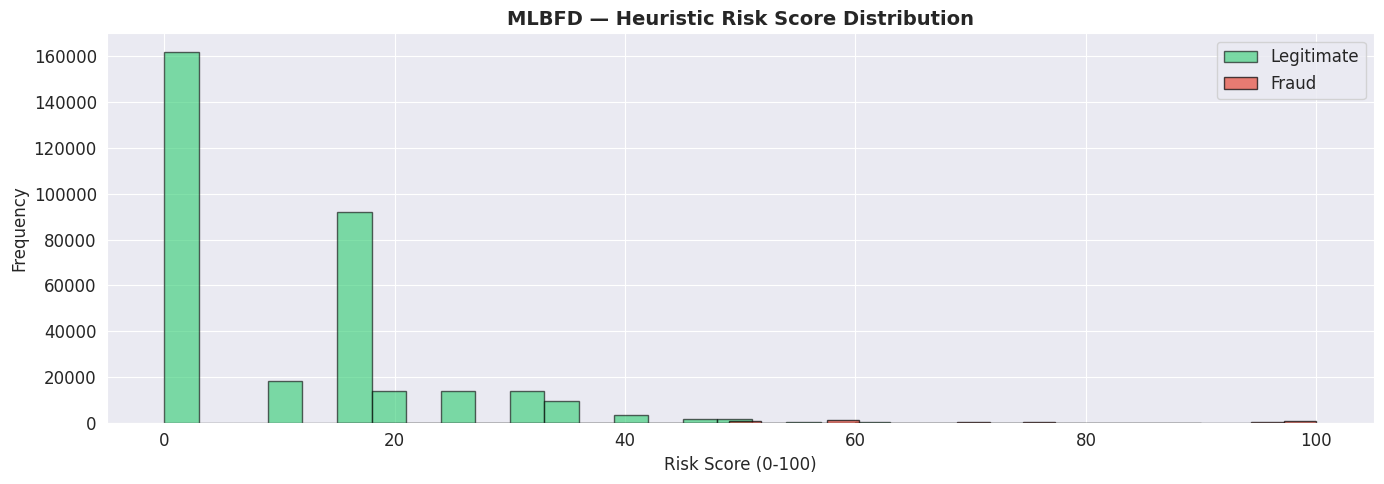

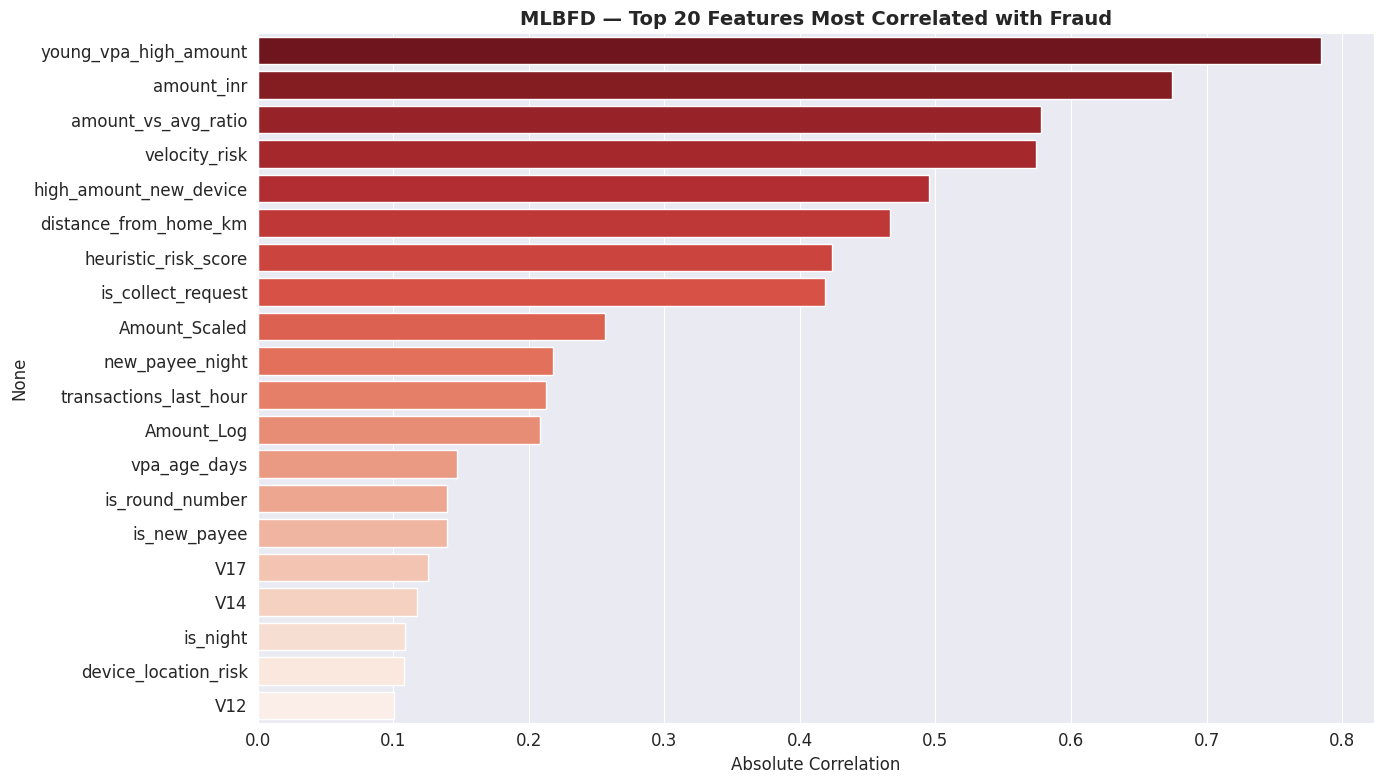

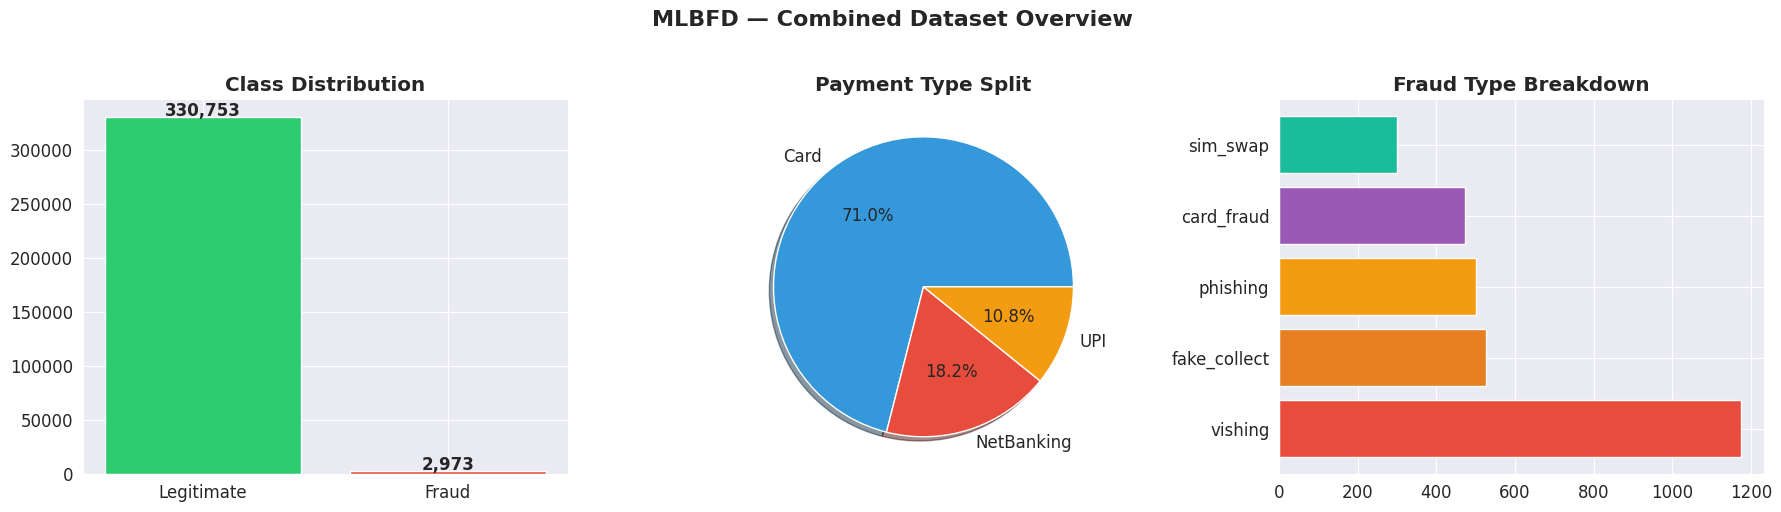


💾 Saving final datasets...

📁 FILE VERIFICATION
  ✅ mlbfd_kaggle_cleaned.csv                 — 156.11 MB (283,726 rows)
  ✅ mlbfd_indian_synthetic.csv               — 8.85 MB (50,000 rows)
  ✅ mlbfd_combined_dataset.csv               — 195.63 MB (333,726 rows)
  ✅ mlbfd_ml_ready.csv                       — 178.24 MB (333,726 rows)
  ✅ mlbfd_label_encoders.pkl                 — 0.00 MB
  ✅ mlbfd_user_profiles.csv                  — 0.42 MB (1,000 users)

📊 Visualizations:
  ✅ mlbfd_class_distribution.png
  ✅ mlbfd_amount_distribution.png
  ✅ mlbfd_time_distribution.png
  ✅ mlbfd_correlation_heatmap.png
  ✅ mlbfd_indian_fraud_types.png
  ✅ mlbfd_hourly_pattern.png
  ✅ mlbfd_amount_fraud_vs_legit.png
  ✅ mlbfd_state_fraud_rate.png
  ✅ mlbfd_feature_comparison.png
  ✅ mlbfd_heuristic_risk_distribution.png
  ✅ mlbfd_top_features_correlation.png
  ✅ mlbfd_combined_dataset_overview.png

MLBFD — PHASE 1 COMPLETE ✅
Multi-Layer Behavioral Fraud Detection System
for Indian Digital Payments Using

In [5]:
# ============================================================
# MLBFD — PHASE 1, STEP 3 (FIXED)
# Multi-Layer Behavioral Fraud Detection System
# for Indian Digital Payments Using Machine Learning
# ============================================================
# Combine Kaggle + Indian Dataset + Final Feature Engineering
# Notebook: MLBFD_Phase1_Data_Preparation.ipynb
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

PROJECT_NAME = "MLBFD — Multi-Layer Behavioral Fraud Detection"
print(f"{'='*60}")
print(f"  {PROJECT_NAME}")
print(f"  Phase 1, Step 3: Combine & Feature Engineering")
print(f"{'='*60}")

# --- 3.1 Smart File Loader — Finds files wherever they are ---
def find_file(filename):
    """Search for a file in common Colab directories"""
    # Check current directory first
    if os.path.exists(filename):
        return filename

    # Check common Colab paths
    search_dirs = ['/content', '/content/drive/MyDrive', os.getcwd()]
    for directory in search_dirs:
        for root, dirs, files in os.walk(directory):
            if filename in files:
                full_path = os.path.join(root, filename)
                print(f"  📁 Found {filename} at: {full_path}")
                return full_path

    # If prefixed version not found, try without prefix
    alt_name = filename.replace('mlbfd_', '')
    for directory in search_dirs:
        for root, dirs, files in os.walk(directory):
            if alt_name in files:
                full_path = os.path.join(root, alt_name)
                print(f"  📁 Found alternate {alt_name} at: {full_path}")
                return full_path

    raise FileNotFoundError(f"❌ Cannot find {filename} or {alt_name}. Please re-run Cell 1 and Cell 2.")

print("\n🔍 Locating dataset files...")
kaggle_path = find_file('mlbfd_kaggle_cleaned.csv')
indian_path = find_file('mlbfd_indian_synthetic.csv')

df_kaggle = pd.read_csv(kaggle_path)
df_indian = pd.read_csv(indian_path)

print(f"\n{'='*60}")
print("DATASETS LOADED SUCCESSFULLY")
print(f"{'='*60}")
print(f"Kaggle dataset  : {len(df_kaggle):,} rows, {df_kaggle.shape[1]} cols")
print(f"Indian dataset  : {len(df_indian):,} rows, {df_indian.shape[1]} cols")

# --- 3.2 Standardize Kaggle Dataset to Match Indian Format ---
print(f"\n📊 Mapping Kaggle features to Indian format...")

df_kaggle_mapped = pd.DataFrame({
    'transaction_id': [f'KGL_{i:06d}' for i in range(len(df_kaggle))],
    'user_id': [f'KGL_USR_{i % 2000:04d}' for i in range(len(df_kaggle))],
    'amount_inr': df_kaggle['Amount'],
    'hour_ist': df_kaggle['Hour'],
    'day_of_week': np.random.randint(0, 7, len(df_kaggle)),
    'payment_type': np.random.choice(['Card', 'NetBanking'], len(df_kaggle), p=[0.8, 0.2]),
    'payment_app': 'Bank',
    'merchant_category': np.random.choice(
        ['shopping', 'food_delivery', 'travel', 'entertainment', 'fuel', 'grocery'],
        len(df_kaggle)),
    'is_new_payee': (np.random.random(len(df_kaggle)) < 0.3).astype(int),
    'is_known_device': (np.random.random(len(df_kaggle)) > 0.1).astype(int),
    'state': np.random.choice(list(['Maharashtra', 'Karnataka', 'Delhi', 'Tamil Nadu',
                                      'Telangana', 'Gujarat', 'UP', 'West Bengal']),
                               len(df_kaggle)),
    'is_usual_location': (np.random.random(len(df_kaggle)) > 0.15).astype(int),
    'distance_from_home_km': np.random.exponential(10, len(df_kaggle)).round(1),
    'vpa_age_days': np.random.randint(1, 1000, len(df_kaggle)),
    'is_round_number': (df_kaggle['Amount'] % 100 == 0).astype(int),
    'amount_vs_avg_ratio': 1.0,
    'transactions_last_hour': np.random.randint(0, 3, len(df_kaggle)),
    'transactions_last_24h': np.random.randint(1, 10, len(df_kaggle)),
    'is_vpn': (np.random.random(len(df_kaggle)) < 0.02).astype(int),
    'is_collect_request': 0,
    'fraud_type': df_kaggle['Class'].map({0: 'none', 1: 'card_fraud'}),
    'is_fraud': df_kaggle['Class'],
    **{f'V{i}': df_kaggle[f'V{i}'] for i in range(1, 29)},
    'Amount_Scaled': df_kaggle['Amount_Scaled'],
    'Amount_Log': df_kaggle['Amount_Log'],
})

# Adjust fraud rows for realism
fraud_mask = df_kaggle_mapped['is_fraud'] == 1
df_kaggle_mapped.loc[fraud_mask, 'is_new_payee'] = np.random.choice([0, 1], fraud_mask.sum(), p=[0.2, 0.8])
df_kaggle_mapped.loc[fraud_mask, 'is_known_device'] = np.random.choice([0, 1], fraud_mask.sum(), p=[0.6, 0.4])
df_kaggle_mapped.loc[fraud_mask, 'distance_from_home_km'] = np.random.exponential(100, fraud_mask.sum()).round(1)
df_kaggle_mapped.loc[fraud_mask, 'is_usual_location'] = np.random.choice([0, 1], fraud_mask.sum(), p=[0.7, 0.3])
df_kaggle_mapped.loc[fraud_mask, 'transactions_last_hour'] = np.random.randint(2, 8, fraud_mask.sum())
df_kaggle_mapped.loc[fraud_mask, 'vpa_age_days'] = np.random.randint(1, 30, fraud_mask.sum())

print(f"✅ Kaggle dataset mapped to Indian format")

# --- 3.3 Add PCA features as zeros for Indian dataset ---
for i in range(1, 29):
    if f'V{i}' not in df_indian.columns:
        df_indian[f'V{i}'] = 0.0
if 'Amount_Scaled' not in df_indian.columns:
    df_indian['Amount_Scaled'] = (df_indian['amount_inr'] - df_indian['amount_inr'].mean()) / df_indian['amount_inr'].std()
if 'Amount_Log' not in df_indian.columns:
    df_indian['Amount_Log'] = np.log1p(df_indian['amount_inr'])

# --- 3.4 Combine ---
common_cols = list(set(df_kaggle_mapped.columns) & set(df_indian.columns))
common_cols.sort()

print(f"\n📊 Merging datasets on {len(common_cols)} common columns...")

df_combined = pd.concat([
    df_kaggle_mapped[common_cols],
    df_indian[common_cols]
], ignore_index=True)

df_combined = df_combined.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n{'='*60}")
print("COMBINED DATASET — SUMMARY")
print(f"{'='*60}")
print(f"Total Transactions  : {len(df_combined):,}")
print(f"Total Features      : {df_combined.shape[1]}")
print(f"Fraud Cases         : {df_combined['is_fraud'].sum():,} ({df_combined['is_fraud'].mean()*100:.2f}%)")
print(f"Legitimate Cases    : {(df_combined['is_fraud']==0).sum():,}")

# --- 3.5 Advanced Feature Engineering ---
print(f"\n{'='*60}")
print("ADVANCED FEATURE ENGINEERING")
print(f"{'='*60}")

# Time-based features
df_combined['is_night'] = ((df_combined['hour_ist'] >= 23) | (df_combined['hour_ist'] <= 5)).astype(int)
df_combined['is_weekend'] = (df_combined['day_of_week'] >= 5).astype(int)
df_combined['is_business_hours'] = ((df_combined['hour_ist'] >= 9) & (df_combined['hour_ist'] <= 18)).astype(int)

# Risk scoring features
df_combined['device_location_risk'] = (
    (1 - df_combined['is_known_device']) + (1 - df_combined['is_usual_location'])
).astype(int)

df_combined['velocity_risk'] = (
    (df_combined['transactions_last_hour'] > 3).astype(int) +
    (df_combined['transactions_last_24h'] > 10).astype(int)
)

df_combined['new_payee_night'] = (
    (df_combined['is_new_payee'] == 1) & (df_combined['is_night'] == 1)
).astype(int)

df_combined['high_amount_new_device'] = (
    (df_combined['amount_vs_avg_ratio'] > 3) & (df_combined['is_known_device'] == 0)
).astype(int)

df_combined['young_vpa_high_amount'] = (
    (df_combined['vpa_age_days'] < 30) & (df_combined['amount_vs_avg_ratio'] > 2)
).astype(int)

# Distance bins
df_combined['distance_category'] = pd.cut(
    df_combined['distance_from_home_km'],
    bins=[0, 10, 50, 200, 1000, float('inf')],
    labels=['home', 'local', 'city', 'state', 'interstate']
)

# Composite heuristic risk score
df_combined['heuristic_risk_score'] = (
    df_combined['is_new_payee'] * 15 +
    (1 - df_combined['is_known_device']) * 20 +
    (1 - df_combined['is_usual_location']) * 15 +
    df_combined['is_night'] * 10 +
    df_combined['is_vpn'] * 25 +
    df_combined['is_collect_request'] * 20 +
    (df_combined['vpa_age_days'] < 30).astype(int) * 15 +
    (df_combined['amount_vs_avg_ratio'] > 5).astype(int) * 20 +
    (df_combined['transactions_last_hour'] > 3).astype(int) * 10 +
    (df_combined['distance_from_home_km'] > 500).astype(int) * 15
)
df_combined['heuristic_risk_score'] = df_combined['heuristic_risk_score'].clip(0, 100)

new_features = [
    'is_night', 'is_weekend', 'is_business_hours',
    'device_location_risk', 'velocity_risk',
    'new_payee_night', 'high_amount_new_device', 'young_vpa_high_amount',
    'distance_category', 'heuristic_risk_score'
]
print(f"✅ Added {len(new_features)} engineered features")
print(f"   Total features now: {df_combined.shape[1]}")

# --- 3.6 Final Visualizations ---
print(f"\n📊 Generating visualizations...")

# Viz 1: Heuristic Risk Score Distribution
fig, ax = plt.subplots(figsize=(14, 5))
ax.hist(df_combined[df_combined['is_fraud']==0]['heuristic_risk_score'], bins=30,
        color='#2ecc71', alpha=0.6, label='Legitimate', edgecolor='black')
ax.hist(df_combined[df_combined['is_fraud']==1]['heuristic_risk_score'], bins=30,
        color='#e74c3c', alpha=0.7, label='Fraud', edgecolor='black')
ax.set_title('MLBFD — Heuristic Risk Score Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Risk Score (0-100)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('mlbfd_heuristic_risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Viz 2: Top 20 Features Correlated with Fraud
fig, ax = plt.subplots(figsize=(14, 8))
numeric_cols = df_combined.select_dtypes(include=[np.number]).columns
fraud_corr = df_combined[numeric_cols].corr()['is_fraud'].drop('is_fraud').abs().sort_values(ascending=False).head(20)
sns.barplot(x=fraud_corr.values, y=fraud_corr.index, palette='Reds_r', ax=ax)
ax.set_title('MLBFD — Top 20 Features Most Correlated with Fraud', fontsize=14, fontweight='bold')
ax.set_xlabel('Absolute Correlation')
plt.tight_layout()
plt.savefig('mlbfd_top_features_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Viz 3: Combined Dataset Overview
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

class_counts = df_combined['is_fraud'].value_counts()
axes[0].bar(['Legitimate', 'Fraud'], class_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Class Distribution', fontweight='bold')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

pt_counts = df_combined['payment_type'].value_counts()
axes[1].pie(pt_counts.values, labels=pt_counts.index, autopct='%1.1f%%',
            colors=['#3498db', '#e74c3c', '#f39c12'], shadow=True)
axes[1].set_title('Payment Type Split', fontweight='bold')

ft_counts = df_combined[df_combined['is_fraud']==1]['fraud_type'].value_counts()
axes[2].barh(ft_counts.index, ft_counts.values, color=['#e74c3c', '#e67e22', '#f39c12', '#9b59b6', '#1abc9c'])
axes[2].set_title('Fraud Type Breakdown', fontweight='bold')

plt.suptitle('MLBFD — Combined Dataset Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('mlbfd_combined_dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 3.7 Save Final Combined Dataset ---
print(f"\n💾 Saving final datasets...")

df_combined.to_csv('mlbfd_combined_dataset.csv', index=False)

# ML-ready version (numeric features only)
ml_drop_cols = ['transaction_id', 'user_id', 'timestamp', 'payee_vpa', 'payer_vpa',
                'device_id', 'device_model', 'city', 'fraud_type', 'distance_category']
ml_cols_to_drop = [c for c in ml_drop_cols if c in df_combined.columns]
df_ml = df_combined.drop(columns=ml_cols_to_drop)

# Encode categorical features
from sklearn.preprocessing import LabelEncoder
le_cols = ['payment_type', 'payment_app', 'merchant_category', 'state']
label_encoders = {}
for col in le_cols:
    if col in df_ml.columns:
        le = LabelEncoder()
        df_ml[col] = le.fit_transform(df_ml[col].astype(str))
        label_encoders[col] = le

df_ml.to_csv('mlbfd_ml_ready.csv', index=False)

# Save label encoders
import pickle
with open('mlbfd_label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

# --- 3.8 Verify All Files Exist ---
print(f"\n{'='*60}")
print("📁 FILE VERIFICATION")
print(f"{'='*60}")

all_files = [
    ('mlbfd_kaggle_cleaned.csv', len(df_kaggle)),
    ('mlbfd_indian_synthetic.csv', len(df_indian)),
    ('mlbfd_combined_dataset.csv', len(df_combined)),
    ('mlbfd_ml_ready.csv', len(df_ml)),
    ('mlbfd_label_encoders.pkl', None),
]

all_found = True
for fname, expected_rows in all_files:
    # Check in current dir or find it
    exists = os.path.exists(fname)
    if exists:
        size_mb = os.path.getsize(fname) / (1024*1024)
        row_info = f" ({expected_rows:,} rows)" if expected_rows else ""
        print(f"  ✅ {fname:40s} — {size_mb:.2f} MB{row_info}")
    else:
        print(f"  ❌ {fname:40s} — NOT FOUND")
        all_found = False

# Check user profiles
user_profile_path = find_file('mlbfd_user_profiles.csv') if not os.path.exists('mlbfd_user_profiles.csv') else 'mlbfd_user_profiles.csv'
if os.path.exists(user_profile_path):
    size_mb = os.path.getsize(user_profile_path) / (1024*1024)
    print(f"  ✅ {'mlbfd_user_profiles.csv':40s} — {size_mb:.2f} MB (1,000 users)")

# Check visualizations
print(f"\n📊 Visualizations:")
viz_files = [
    'mlbfd_class_distribution.png',
    'mlbfd_amount_distribution.png',
    'mlbfd_time_distribution.png',
    'mlbfd_correlation_heatmap.png',
    'mlbfd_indian_fraud_types.png',
    'mlbfd_hourly_pattern.png',
    'mlbfd_amount_fraud_vs_legit.png',
    'mlbfd_state_fraud_rate.png',
    'mlbfd_feature_comparison.png',
    'mlbfd_heuristic_risk_distribution.png',
    'mlbfd_top_features_correlation.png',
    'mlbfd_combined_dataset_overview.png'
]
viz_count = 0
for vf in viz_files:
    if os.path.exists(vf):
        viz_count += 1
        print(f"  ✅ {vf}")
    else:
        print(f"  ❌ {vf}")

# --- 3.9 Final Summary ---
print(f"\n{'='*60}")
print("MLBFD — PHASE 1 COMPLETE ✅")
print("Multi-Layer Behavioral Fraud Detection System")
print("for Indian Digital Payments Using Machine Learning")
print(f"{'='*60}")

print(f"\n📋 Final Dataset Specs:")
print(f"   Total rows        : {len(df_combined):,}")
print(f"   Total features    : {df_ml.shape[1]}")
print(f"   Fraud cases       : {df_combined['is_fraud'].sum():,}")
print(f"   Legitimate cases  : {(df_combined['is_fraud']==0).sum():,}")
print(f"   Fraud ratio       : {df_combined['is_fraud'].mean()*100:.2f}%")
print(f"   Data files        : 6 CSV/PKL files saved")
print(f"   Visualizations    : {viz_count}/12 charts saved")
print(f"   SMOTE needed      : YES (will balance in Phase 2)")

print(f"\n{'='*60}")
print("→ NEXT: Phase 2 — ML Model Training")
print("  Open: MLBFD_Phase2_Model_Training.ipynb")
print("  Ask : 'Start Phase 2 — train all ML models'")
print(f"{'='*60}")

In [6]:
# ============================================================
# MLBFD — DOWNLOAD ALL PHASE 1 FILES
# ============================================================

import os
import zipfile
from google.colab import files

zip_filename = 'MLBFD_Phase1_Complete.zip'

with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for f in os.listdir('/content'):
        if f.startswith('mlbfd_') and (f.endswith('.csv') or f.endswith('.pkl') or f.endswith('.png')):
            if f.endswith('.csv'):
                zip_path = f'MLBFD_Phase1/Data/{f}'
            elif f.endswith('.pkl'):
                zip_path = f'MLBFD_Phase1/Models/{f}'
            else:
                zip_path = f'MLBFD_Phase1/Visualizations/{f}'

            zipf.write(f'/content/{f}', zip_path)
            size = os.path.getsize(f'/content/{f}') / (1024*1024)
            print(f"  ✅ {f:45s} ({size:.2f} MB)")

zip_size = os.path.getsize(zip_filename) / (1024*1024)
print(f"\n📦 ZIP ready: {zip_filename} ({zip_size:.2f} MB)")
print(f"⬇️  Downloading now...\n")

files.download(zip_filename)

  ✅ mlbfd_indian_synthetic.csv                    (8.85 MB)
  ✅ mlbfd_combined_dataset.csv                    (195.63 MB)
  ✅ mlbfd_amount_distribution.png                 (0.07 MB)
  ✅ mlbfd_time_distribution.png                   (0.05 MB)
  ✅ mlbfd_kaggle_cleaned.csv                      (156.11 MB)
  ✅ mlbfd_ml_ready.csv                            (178.24 MB)
  ✅ mlbfd_correlation_heatmap.png                 (0.13 MB)
  ✅ mlbfd_user_profiles.csv                       (0.42 MB)
  ✅ mlbfd_top_features_correlation.png            (0.11 MB)
  ✅ mlbfd_feature_comparison.png                  (0.15 MB)
  ✅ mlbfd_indian_fraud_types.png                  (0.10 MB)
  ✅ mlbfd_heuristic_risk_distribution.png         (0.06 MB)
  ✅ mlbfd_amount_fraud_vs_legit.png               (0.06 MB)
  ✅ mlbfd_hourly_pattern.png                      (0.05 MB)
  ✅ mlbfd_combined_dataset_overview.png           (0.12 MB)
  ✅ mlbfd_state_fraud_rate.png                    (0.07 MB)
  ✅ mlbfd_label_encoders.pkl      

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>